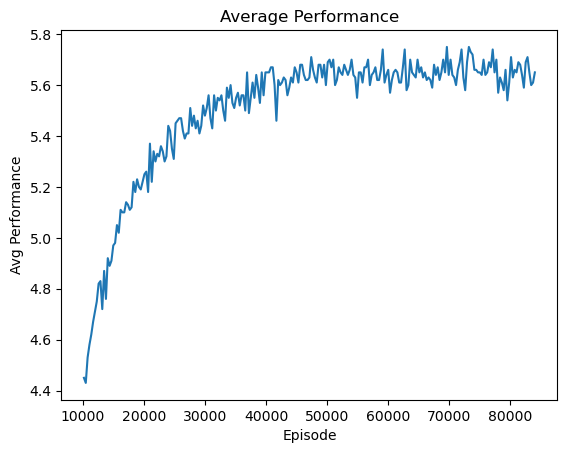

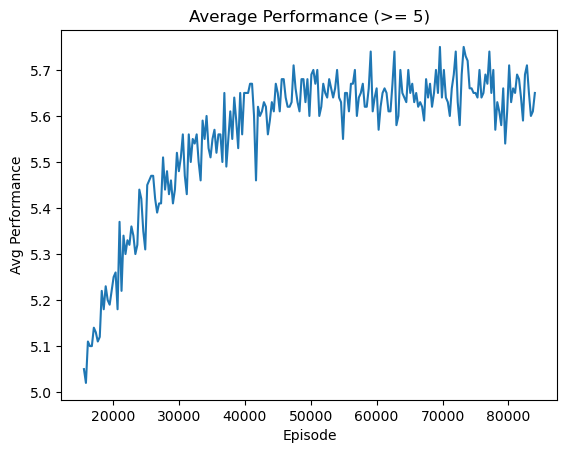

In [21]:
import re
import matplotlib.pyplot as plt

def plot_avg_performance_from_log(filepath, min_perf=None):
    episodes = []
    perf = []

    with open(filepath, 'r') as f:
        for line in f:
            if "Avg Performance" in line:
                ep_match = re.search(r"Episode\s+(\d+)", line)
                perf_match = re.search(r"Avg Performance:\s*(-?\d+\.\d+)", line)
                
                if ep_match and perf_match:
                    episodes.append(int(ep_match.group(1)))
                    perf.append(float(perf_match.group(1)))

    if min_perf is not None:
        episodes = [e for e, p in zip(episodes, perf) if p >= min_perf]
        perf = [p for p in perf if p >= min_perf]

    plt.figure() 
    plt.plot(episodes, perf)
    plt.xlabel("Episode")
    plt.ylabel("Avg Performance")
    title = "Average Performance"
    if min_perf is not None:
        title += f" (>= {min_perf})"
    plt.title(title)
    plt.show()


# usage examples:
 
plot_avg_performance_from_log("training_log.txt")

# high-performance zoom:
plot_avg_performance_from_log("training_log.txt", min_perf=5)